In [13]:
# Import essential libraries
import os
import numpy as np
import pandas as pd

In [14]:
# Import TensorFlow for building and training machine learning models
import tensorflow as tf

# Import Matplotlib's pyplot module for data visualisation and plotting
import matplotlib.pyplot as plt

# Import Scikit-learn for evaluation metrics such as classification reports
from sklearn.metrics import classification_report

In [15]:
# Import custom loss functions and evaluation metrics for segmentation tasks
from Components.segmentation_utils import Losses, Metrics

# Import U-Net model variants for segmentation
from Components.unet_models import ModifiedUNet, DoubleUNet

# Import a custom optimiser
from Components.model_optimisers import HnAdam

In [16]:
# Import project-specific constants and path definitions
from Components.definitions import *

# Print key dataset and file paths for verification
print(f"Dataset path: {DATA_ROOT}")
print(f"Meta path: {Paths.metadata_csv}")
print(f"Mass training data path: {Paths.new_mass_train_csv}")
print(f"Mass test data path: {Paths.new_mass_test_csv}")
print(f"Mass train tensor path: {Paths.mass_train_tensor_dir}")
print(f"Mass test tensor path: {Paths.mass_test_tensor_dir}")

Dataset path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688
Meta path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/metadata.csv
Mass training data path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/new_mass_case_description_train_set.csv
Mass test data path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/new_mass_case_description_test_set.csv
Mass train tensor path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/mass_tensor/train
Mass test tensor path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/mass_tensor/test


In [17]:
history_path = os.path.join(DATA_ROOT, 'history.csv')
full_model_path = os.path.join(DATA_ROOT, 'mass_model.keras')
best_model_path = os.path.join(DATA_ROOT, 'best_mass_model.keras')

# History

### Load history

In [18]:
# Load the training history from the CSV file
history_df = pd.read_csv(history_path)

# Display the last row of the dataframe to see the final training metrics
history_df.tail(1)

,accuracy,dice_coef,jaccard_index,loss,val_accuracy,val_dice_coef,val_jaccard_index,val_loss,fold
999,0.999623,0.961041,0.936026,0.020406,0.998938,0.909304,0.859661,0.053875,9


In [21]:
# Select and display the rows where the validation Dice coefficient or Jaccard index reached their maximum values
history_df.loc[history_df[['val_dice_coef']].idxmax().unique()]

,accuracy,dice_coef,jaccard_index,loss,val_accuracy,val_dice_coef,val_jaccard_index,val_loss,fold
700,0.999496,0.945204,0.912284,0.028994,0.999737,0.980583,0.964766,0.01124,7


### Visualise history

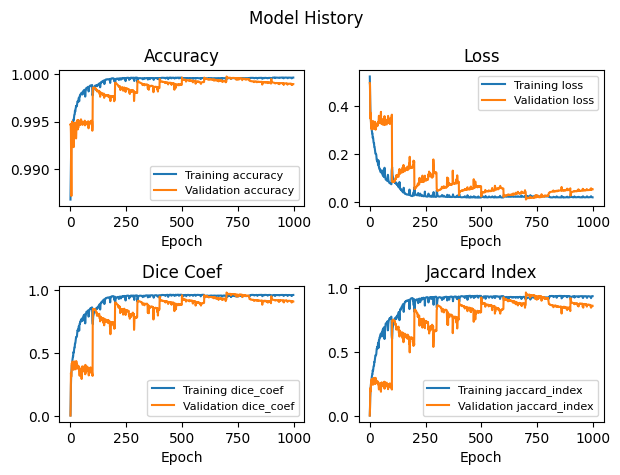

In [22]:
# Visualise the training and validation metrics over epochs using subplots
fig, ax = plt.subplots(2, 2)
fig.suptitle('Model History')
fontsize = 8

# Plot training and validation accuracy
ax[0,0].plot(history_df['accuracy'], label='Training accuracy')
ax[0,0].plot(history_df['val_accuracy'], label='Validation accuracy')
ax[0,0].set_title('Accuracy')
ax[0,0].set_xlabel('Epoch')
ax[0,0].legend(fontsize=fontsize)

# Plot training and validation loss
ax[0,1].plot(history_df['loss'], label='Training loss')
ax[0,1].plot(history_df['val_loss'], label='Validation loss')
ax[0,1].set_title('Loss')
ax[0,1].set_xlabel('Epoch')
ax[0,1].legend(fontsize=fontsize)

# Plot training and validation Dice coefficient
ax[1,0].plot(history_df['dice_coef'], label='Training dice_coef')
ax[1,0].plot(history_df['val_dice_coef'], label='Validation dice_coef')
ax[1,0].set_title('Dice Coef')
ax[1,0].set_xlabel('Epoch')
ax[1,0].legend(fontsize=fontsize)

# Plot training and validation Jaccard index
ax[1,1].plot(history_df['jaccard_index'], label='Training jaccard_index')
ax[1,1].plot(history_df['val_jaccard_index'], label='Validation jaccard_index')
ax[1,1].set_title('Jaccard Index')
ax[1,1].set_xlabel('Epoch')
ax[1,1].legend(fontsize=fontsize)

plt.tight_layout()
plt.show()

# Model

In [23]:
# Load the previously saved model from disk, including any custom loss functions and metrics
full_model = tf.keras.models.load_model(
    full_model_path,
    custom_objects={
        'ModifiedUNet': ModifiedUNet,
        'combined_loss': Losses.combined_loss,
        'dice_coef': Metrics.dice_coef,
        'jaccard_index': Metrics.jaccard_index
})


best_model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={
        'ModifiedUNet': ModifiedUNet,
        'combined_loss': Losses.combined_loss,
        'dice_coef': Metrics.dice_coef,
        'jaccard_index': Metrics.jaccard_index
})

Config passed to from_config: {'name': 'modified_u_net', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'input_shape': [128, 128, 3]}
Config passed to from_config: {'name': 'modified_u_net', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'input_shape': [128, 128, 3]}


### Model summary

In [24]:
# Display the architecture summary of the loaded model
full_model.summary()

Model: "modified_u_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Modified_U-Net (Functional)     │ (None, 128, 128, 1)    │    34,513,345 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,540,041 (394.97 MB)

 Trainable params: 34,513,345 (131.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,026,696 (263.32 MB)

### Evaluation

In [25]:
# Load the test dataset from saved TensorFlow dataset directory
test_images = tf.data.Dataset.load(Paths.mass_test_tensor_dir)

# Print the shape of one sample image and its mask from the test dataset
for x, y in test_images.take(1):
    print(f"test image shape: {x.shape}, {y.shape}")

# Calculate the total number of test samples
test_rows = len(test_images)

# Define the size of the validation subset (80% of test data)
val_size = int(0.8 * test_rows)

# Calculate the remaining test subset size
test_size = test_rows - val_size

# Define batch size for evaluation
BATCH_SIZE = 8

# Prepare the test batches by skipping validation samples, taking the test subset, and batching them for evaluation
test_batches = (
    test_images
    .skip(val_size)
    .take(test_size)
    .batch(BATCH_SIZE)
)

test image shape: (128, 128, 3), (128, 128, 1)


2025-07-06 09:58:52.623026: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [26]:
# Evaluate the loaded model on the prepared test batches and store the results
evaluations = best_model.evaluate(test_batches)

print("Evaluation with test dataset:")
print(f"\tLoss: {evaluations[0]:.4f}")
print(f"\tAccuracy: {evaluations[1] * 100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.9997 - dice_coef: 0.9441 - jaccard_index: 0.9118 - loss: 0.0292
Evaluation with test dataset:
	Loss: 0.0170
	Accuracy: 99.98%


### Prediction

In [27]:
# Generate predictions from the loaded model on the test batches
predictions = best_model.predict(test_batches)

# Print the shape of the predictions array
print(f"predictions size: {predictions.shape}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step
predictions size: (76, 128, 128, 1)


In [28]:
# Initialise lists to collect all true and predicted pixels
y_true_all = []
y_pred_all = []

# Iterate over batches in the test dataset
for images, masks in test_batches:
    # Predict masks for current batch
    preds = best_model.predict(images)  # Shape: (batch, 128, 128, 1)

    # Threshold predictions to get binary masks
    preds = (preds > 0.5).astype(np.uint8)

    # Flatten ground truth masks and predictions, convert to integers, and append to lists
    y_true_all.extend(masks.numpy().flatten().astype(np.uint8))
    y_pred_all.extend(preds.flatten())

# Print detailed classification report with precision, recall, f1-score for each class
print(classification_report(y_true_all, y_pred_all))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1238900
           1       0.98      0.98      0.98      6284

    accuracy                           1.00   1245184
   macro avg       0.99      0.99      0.99   1245184
weighted avg       1.00      1.00      1.00   1245184



In [29]:
def display(images):
    """
    Display a list of images side-by-side with titles:
    'Input Image', 'Ground Truth', and 'Predicted Mask'.
    """
    plt.figure(figsize=(7, 7))
    title = ["Input Image", "Ground Truth", "Predicted Mask"]
    
    # Loop over each image and plot it in a subplot
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.utils.array_to_img(images[i])) # Convert tensor to image
        plt.axis("off") # Hide axis for clarity
    plt.show()
    
def create_mask(pred_mask):
    """
    Convert a predicted mask tensor into a binary mask.
    If using multi-class masks (argmax), use the first branch (currently disabled).
    Otherwise, threshold the mask at 0.5 to get binary mask.
    
    Also prints unique values, min/max, and shapes for debugging.
    Returns the first mask in the batch.
    """
    # Threshold prediction at 0.5 to get binary mask
    mask = tf.cast(pred_mask > 0.5, tf.uint8)

    # Return the first mask (remove batch dim)
    return mask[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step


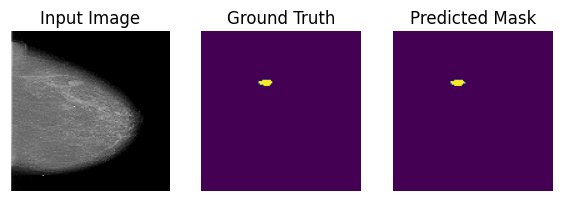

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


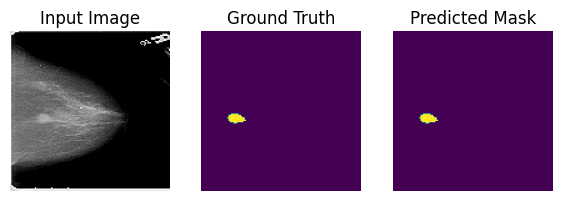

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


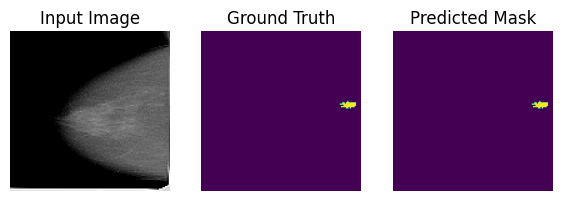

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


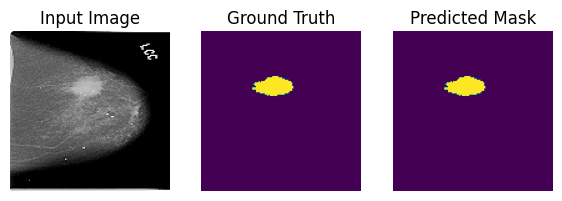

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


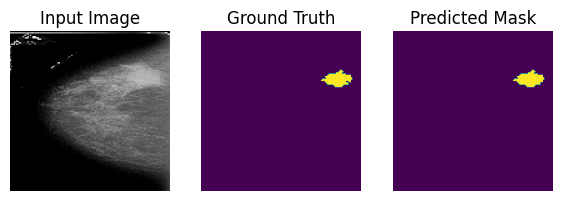

In [30]:
# Number of images/batches to display
image_number = 5

# Iterate through the first 'image_number' batches of test data
for image, mask in test_batches.take(image_number):
    pred_mask = best_model.predict(image) # Predict mask for the batch
    true_mask = mask[0] # Take the first mask in the batch (ground truth)

    # Display input image, true mask, and predicted mask side by side
    display([image[0], true_mask, create_mask(pred_mask)])

#for image, mask in test_batches.shuffle(1000).take(image_number):